# Plot Simulation Results

Unified plotting & reporting for the Qt–Ft simulations. Set everything in the **Settings** cell, then run the **Run** cell — it makes the plots **and** prints the summary **and** writes the data/table exports automatically.

Pick one of three modes:
- `MODE = "single"` — one finished single run (`trajectory.h5` under `Simulation_Files_Single_Runs/`)
- `MODE = "ensemble"` — one ensemble directory under `Different_Particle_Ratios/`
- `MODE = "comparison"` — several ensembles overlaid

Outputs go to a `Plots/` folder inside the run/ensemble directory (or `Plots_Comparison_<labels>/` for comparisons).

## 1. Imports

In [37]:
import importlib
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import qtft
import qtft.config, qtft.system, qtft.engine
import qtft.analysis as analysis
import qtft.plotting as plotting
import qtft.comparison as ae
from qtft import SimulationConfig

# Dev helper: reload submodules after editing the qtft .py files (restart the kernel for deep changes).
for _m in (qtft.config, qtft.system, qtft.engine, qtft.analysis, qtft.plotting,
           qtft.comparison, qtft):
    importlib.reload(_m)
analysis = qtft.analysis
plotting = qtft.plotting
ae       = qtft.comparison
from qtft import SimulationConfig

print("qtft plotting/analysis/comparison modules loaded")

qtft plotting/analysis/comparison modules loaded


## 2. Settings

In [38]:
# ============================================================
# PLOT SETTINGS  —  choose what to plot and where the data lives
# ============================================================
MODE = "ensemble"   # "single" | "ensemble" | "comparison"

BASE_DIR = "Simulation_Files_Ensembles"   # parent folder for ensembles / comparisons

# ----- MODE == "single": one finished single run -----
SINGLE_RUN_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_phases6_kon1e-06_aggsteps750000_koff1.2e-08_deaggsteps750000_dt1us_4.5s_loops", 
)
SINGLE_H5     = None   # None -> auto-detect (<run>.h5, or trajectory_combined.h5 for phased runs)
SINGLE_CONFIG = None   # None -> auto-detect (<run>_config.json inside SINGLE_RUN_DIR)

# ----- MODE == "ensemble": one ensemble directory -----
ENSEMBLE_DIR = os.path.join(
    BASE_DIR, "200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops",
)

# ----- MODE == "comparison": several ensembles, {label: directory} -----
ENSEMBLES_TO_COMPARE = {
    "200 Qt 200 Ft":  os.path.join(BASE_DIR, "200Qt_200Ft_LJ_eQQ1.5_eFF1.5_eQF3_kon0.001_dt50ps_100us"),
}

# ----- Plot options -----
SHOW_SPREAD     = False   # overlay per-replica traces (ensemble) / bands (comparison)
# Structural/composition analysis reads particle positions from the recorded trajectory,
# so it works whether or not a run stored the optional particles observable (default off;
# see particles_observable_stride in Run_Simulation).
STRIDE          = 1       # single: frame stride for structural/composition analysis
EXPORT_XYZ      = False   # single: also export an OVITO .xyz (can be large/slow)

print(f"MODE = {MODE!r}")

MODE = 'ensemble'


## 3. Run — plots, summary & data export

✓ Loaded statistics from Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/ensemble_statistics.json
✓ Loaded structural data from Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/ensemble_structural.npz
✓ Loaded configuration from Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/ensemble_config.json
Ensemble: Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops
Plots/exports -> Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/


Generating ensemble thesis panel...
✓ Saved panel to Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/ensemble_panel.svg
✓ Saved panel to Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/ensemble_panel.png


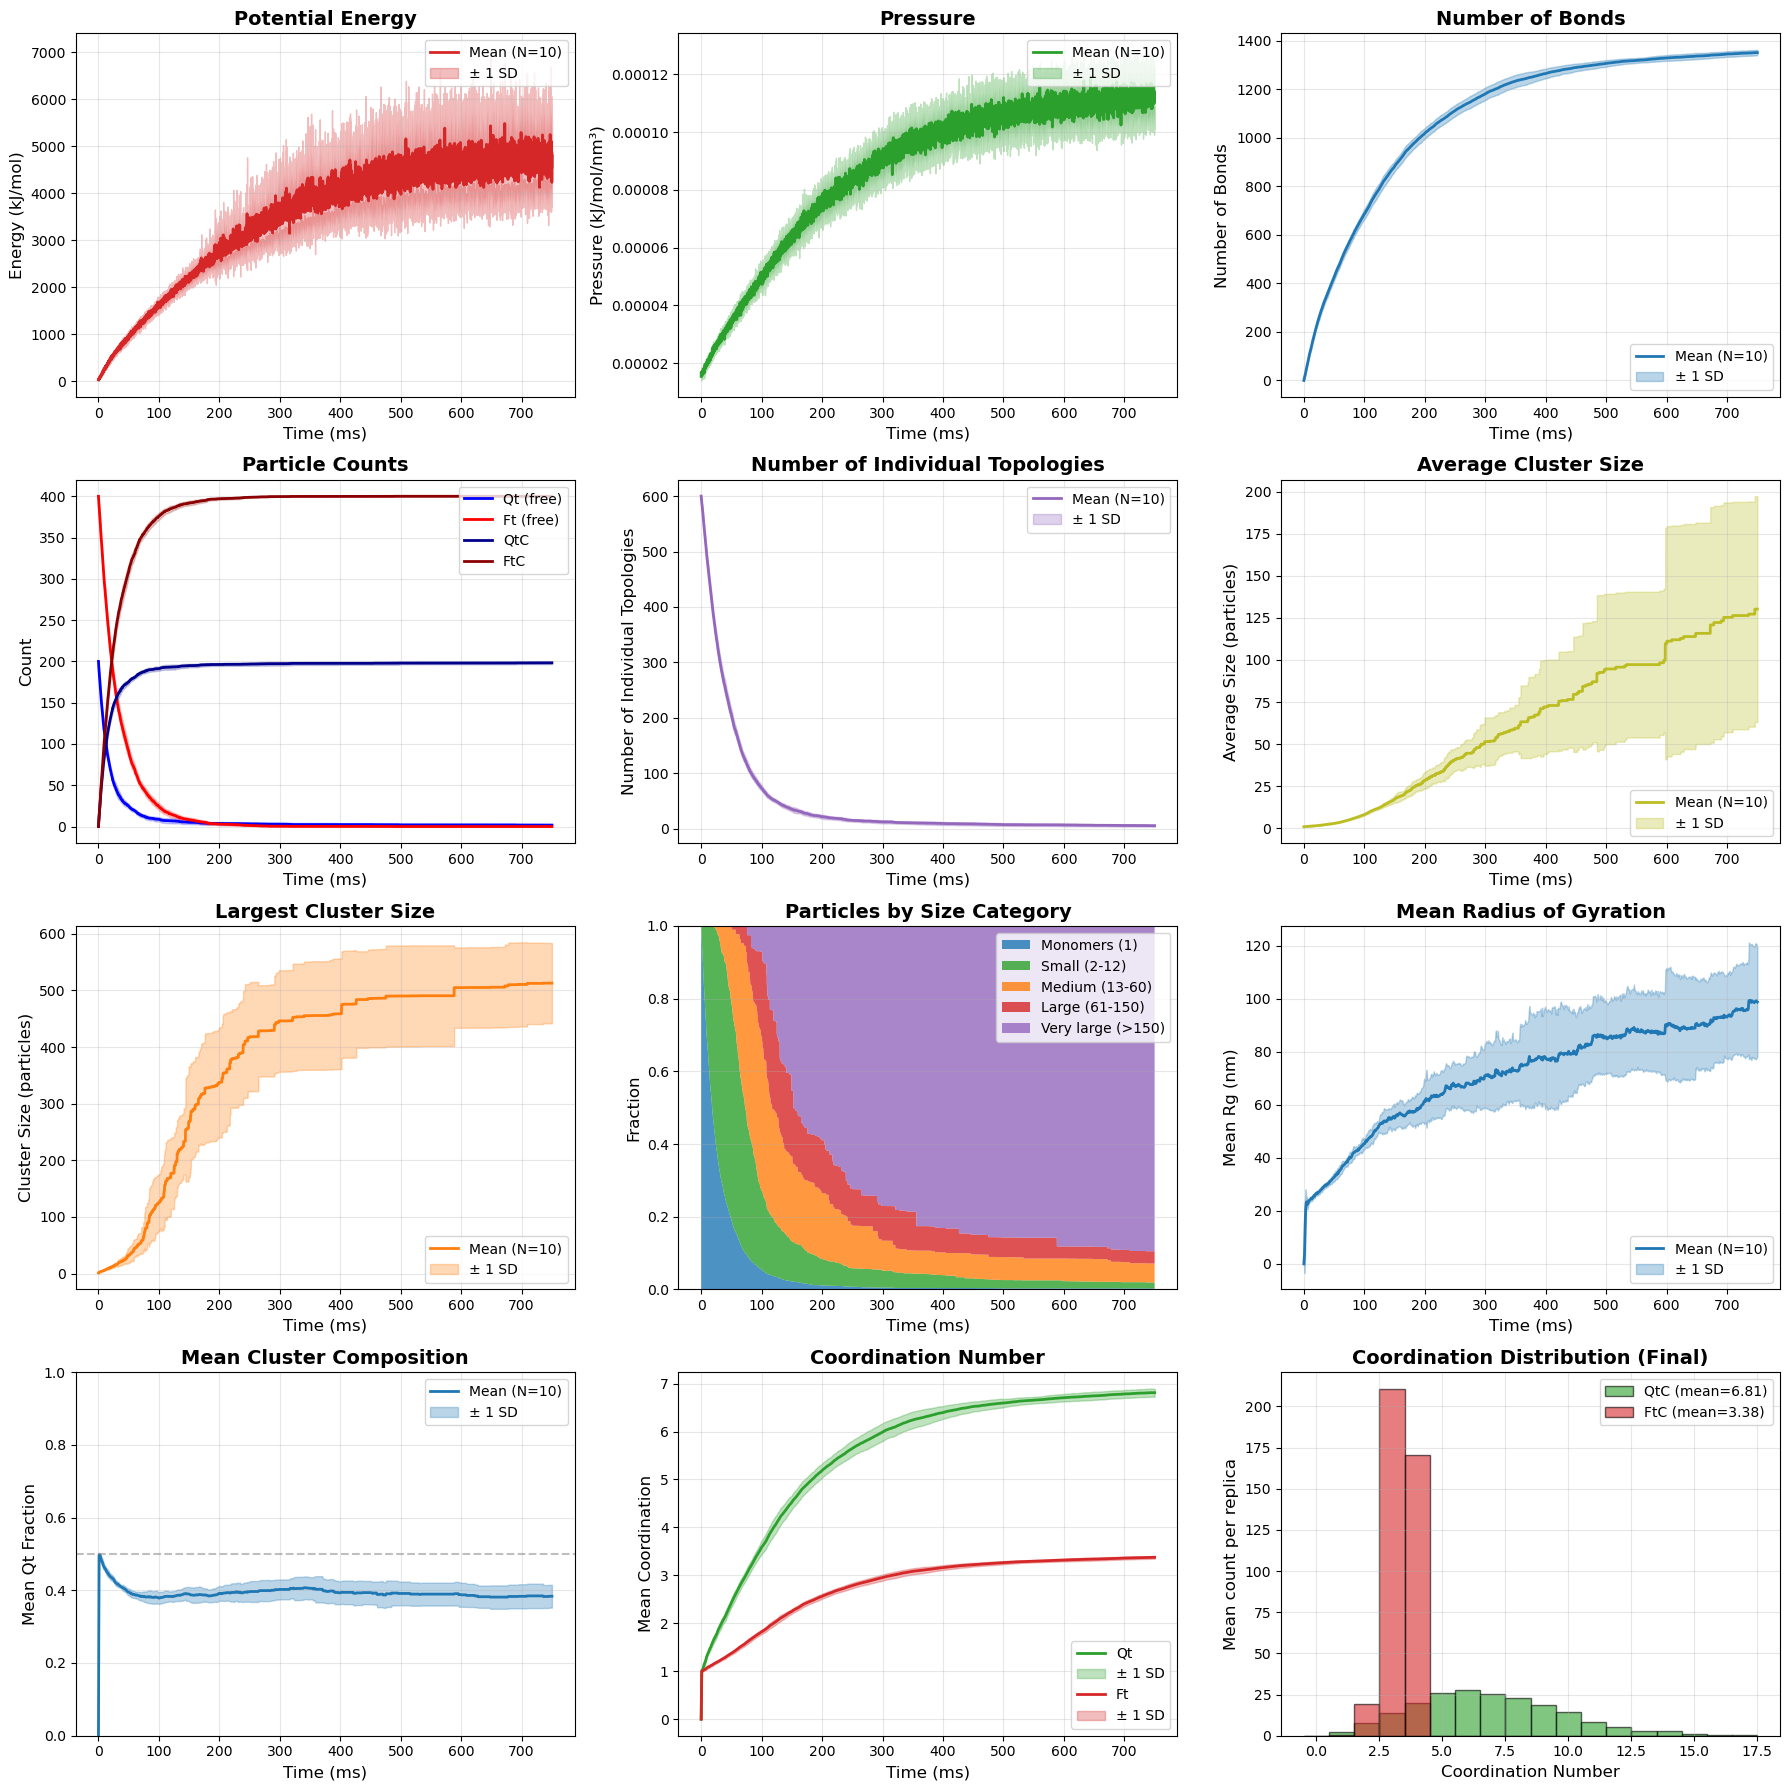


ENSEMBLE SUMMARY (N=10 replicas)

System: 200 Qt + 400 Ft particles

Final state metrics:
  Bonds: 1350.4 ± 11.2
  Largest cluster: 85.5% ± 11.8% of particles
  Half-time: 98300.00 ± 4577.99 µs

✓ Saved table to Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/final_state_table.csv
✓ Saved table to Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/final_state_table.tex
Saved tables/CSV to Simulation_Files_Ensembles/200Qt_400Ft_soft_kQQ4_kFF3_kQF1.5_kon1e-06_dt1us_750ms_loops/Plots/


,Value,Unit
Metric,,
Number of bonds,1350.4 ± 11.2,—
Individual topologies,5.5 ± 1.9,—
Average cluster size,130.2 ± 67.1,particles
Largest cluster size,513.0 ± 71.0,particles
Largest cluster fraction,85.5 ± 11.8,% of particles
Fraction bound,0.996 ± 0.004,—
Half-time t₅₀,98300.00 ± 4577.99,µs
Radius of gyration,98.8 ± 20.5,nm
Qt fraction (QtC/(QtC+FtC)),0.384 ± 0.031,—


In [39]:
# ============================================================
# RUN  —  one dispatch, the same three figures for every MODE
# ============================================================
# Every mode builds a list of labelled (stats, structural, config) triples; MODE decides
# only HOW MANY there are, not which figures appear. Output (identical names everywhere):
#     panel.svg/.png                    12-metric overview
#     kinetics.svg/.png                 bonds / fraction bound / avg cluster size
#     large_clusters_min{N}.svg/.png    clusters at or above MIN_CLUSTER_SIZE

MIN_CLUSTER_SIZE = 5     # count topologies with at least this many particles (inclusive)

triples, kin_series, lcc_series, timestep = [], [], [], None

if MODE == "single":
    run_name = os.path.basename(os.path.normpath(SINGLE_RUN_DIR))
    cfg_path = SINGLE_CONFIG or os.path.join(SINGLE_RUN_DIR, run_name + "_config.json")
    cfg = SimulationConfig.load_json(cfg_path)
    # one resolver knows every layout (plain / replica / phased / uncombined phases)
    h5 = analysis.resolve_trajectory(SINGLE_RUN_DIR, explicit=SINGLE_H5)
    OUT = os.path.join(SINGLE_RUN_DIR, "Plots")
    label = run_name[:40]
    print(f"Single run: {h5}")

    triples.append((label,) + analysis.build_single_run_plotting_data(h5, cfg, stride=STRIDE))
    if cfg.phases:
        phase_files = sorted(glob.glob(os.path.join(SINGLE_RUN_DIR, "phase_*", "trajectory.h5")))
        kin = analysis.load_phased_observables(cfg, phase_files=phase_files or None)
    else:
        kin = analysis.build_kinetics_data_single(h5, cfg)
    kin_series.append({"label": label, "data": kin})
    t, c = analysis.get_large_cluster_counts(h5, MIN_CLUSTER_SIZE)
    lcc_series.append({"label": label, "times": t, "mean": c, "n_replicas": 1})
    timestep = cfg.timestep

elif MODE == "ensemble":
    OUT = os.path.join(ENSEMBLE_DIR, "Plots")
    label = os.path.basename(os.path.normpath(ENSEMBLE_DIR))[:40]
    print(f"Ensemble: {ENSEMBLE_DIR}\n  (the large-cluster count re-reads replicas, ~2 s each)")
    stats, structural, config = analysis.load_ensemble_data(ENSEMBLE_DIR)
    triples.append((label, stats, structural, config))
    kin_series.append({"label": label,
                       "data": analysis.build_kinetics_data_ensemble(stats, config)})
    r = analysis.get_large_cluster_counts_ensemble(ENSEMBLE_DIR, MIN_CLUSTER_SIZE)
    lcc_series.append({"label": label, "times": r["times"], "mean": r["mean"],
                       "std": r["std"], "all": r["all"], "n_replicas": r["n_replicas"]})
    timestep = config.get("timestep", 1e-4)

elif MODE == "comparison":
    _labels = "_".join(l.replace(" ", "") for l in ENSEMBLES_TO_COMPARE)
    OUT = os.path.join(BASE_DIR, "Plots_Comparison_" + _labels)
    print(f"Comparison of {len(ENSEMBLES_TO_COMPARE)} ensembles"
          f"\n  (the large-cluster count re-reads replicas, ~2 s each)")
    for label, d in ENSEMBLES_TO_COMPARE.items():
        stats, structural, config = analysis.load_ensemble_data(d)
        triples.append((label, stats, structural, config))
        kin_series.append({"label": label,
                           "data": analysis.build_kinetics_data_ensemble(stats, config)})
        r = analysis.get_large_cluster_counts_ensemble(d, MIN_CLUSTER_SIZE)
        lcc_series.append({"label": label, "times": r["times"], "mean": r["mean"],
                           "std": r["std"], "n_replicas": r["n_replicas"]})
        if timestep is None:
            timestep = config.get("timestep", 1e-4)

else:
    raise ValueError(f"MODE must be 'single', 'ensemble', or 'comparison', got {MODE!r}")

os.makedirs(OUT, exist_ok=True)
print(f"Plots/exports -> {OUT}/\n")

# ----- the three figures, identical in every mode -----
comp = ae.compare_ensembles(ENSEMBLES_TO_COMPARE) if MODE == "comparison" else None

if comp is None:
    _, stats, structural, config = triples[0]
    plotting.plot_ensemble_panel(stats, structural, config,
                                 show_individual=SHOW_SPREAD,
                                 save_path_base=os.path.join(OUT, "panel"))
else:
    plotting.plot_comparison_panel(comp, show_bands=SHOW_SPREAD,
                                   save_path_base=os.path.join(OUT, "panel"))

plotting.plot_kinetics(kin_series, save_path_base=os.path.join(OUT, "kinetics"))
plotting.plot_large_cluster_count(lcc_series, MIN_CLUSTER_SIZE, timestep,
                                  show_individual=SHOW_SPREAD,
                                  save_path_base=os.path.join(OUT, f"large_clusters_min{MIN_CLUSTER_SIZE}"))
plt.show()

# ----- summary (per-mode reporting; not a figure, so it does not affect the contract) -----
if MODE == "single":
    analysis.print_analysis_summary(h5, cfg)
elif MODE == "ensemble":
    analysis.print_ensemble_summary(triples[0][1], triples[0][3])
else:
    ae.print_parameter_differences(comp)

# ----- tables -----
if comp is None:
    # one target -> its final-state table
    _, stats, structural, config = triples[0]
    analysis.save_table_files(
        analysis.build_final_state_table(stats, config, structural),
        os.path.join(OUT, "final_state_table"),
        caption=f"Final-state summary ({triples[0][0]}).", label="tab:final_state")
else:
    # several targets -> ONE cross-ensemble table (the point of comparison mode),
    # plus the persisted comparison object for later reuse
    analysis.save_table_files(
        ae.build_comparison_table(comp),
        os.path.join(OUT, "comparison_table"),
        caption="Final-state comparison across ensembles (mean ± SD).",
        label="tab:comparison")
    ae.save_comparison_data(comp, os.path.join(OUT, "comparison_data"))

# ----- time-series CSV per target -----
for label, stats, structural, config in triples:
    suffix = "" if len(triples) == 1 else "_" + label.replace(" ", "")
    f = (config.get("timestep", 1e-4) if isinstance(config, dict) else config.timestep) * 1e-3
    pd.DataFrame({
        "time_steps": stats["times"],
        "time_us":    np.asarray(stats["times"]) * f,
        "bonds_mean": stats.get("bonds_mean", []),
        "bonds_std":  stats.get("bonds_std", np.zeros_like(stats.get("bonds_mean", []))),
    }).to_csv(os.path.join(OUT, "bonds" + suffix + ".csv"), index=False)
print(f"Saved tables/CSVs to {OUT}/")

if MODE == "single" and EXPORT_XYZ:
    xyz = os.path.join(OUT, run_name + ".xyz")
    analysis.convert_h5_to_xyz(h5, xyz, cfg, overwrite=True)
    print(f"Exported XYZ: {xyz}")